<a href="https://colab.research.google.com/github/raulmabcn/DataAnalyst/blob/main/Specialization/PythonPandas/S1001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
#Para copiar listas dentro de listas y que no sean referencias a la misma variable.
import copy

# Nivel 1

##1.
Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.

Mostra les primeres 10 files.

Addicionalment, fes un print on comprovi que el DNI només té valors únics.



In [40]:
def open_data_file( file_name, sheet_name, header, index_col ):
  try:
    df = pd.read_excel( f'/content/{file_name}', sheet_name=sheet_name, header=header, index_col=index_col )
  except OSError:
    print(f"Error en la lectura del fichero, comprueba ruta y permisos")
  return df

In [91]:
df = open_data_file( "sprint10.xlsx", "Sheet1", header=3, index_col=0 )

In [92]:
df = df.sort_values(["País d'origen", "Ciutat"])

In [43]:
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [44]:
print(f"Son los DNI's unicos: {df['DNI'].is_unique}")

Son los DNI's unicos: True


##2.
Crea una columna que sigui el nom complet.
Crea una columna si la persona és nascuda a Espanya o no.
Posa el DNI com a índex del DataFrame (noms de files).
Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).
Mostra tots els canvis que has realitzat en una sola taula.

In [93]:
df['Nom Complet'] = df['Nom'].str.cat( df['Cognoms'], sep=" ", na_rep="")

In [94]:
df.loc[df["País d'origen"] == "Espanya" , "Nascuda a Espanya"] = True
df.loc[df["País d'origen"] != "Espanya" , "Nascuda a Espanya"] = False

In [95]:
df = df.set_index('DNI')

In [96]:
df.rename(columns={'Dia de Naixement': 'Dia', 'Mes de Naixement': 'Mes', 'Any de Naixement': 'Any'}, inplace=True)

In [97]:
df['Gènere'] = df['Gènere'].replace( {'H': 'Home', 'D': 'Dona', 'A': 'Altres', 'NC': np.nan} )

In [61]:
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom Complet,Nascuda a Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,False
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,False
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,False


##3.
Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".



In [98]:
df['Fills'] = df['Fills'].apply(lambda x: 'Si' if not np.isnan(x) else 'No')
df.drop( 'No Fills', axis=1, inplace=True )

In [63]:
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascuda a Espanya
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Si,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Si,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Si,Grup D,Jonas Schneider,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,Grup B,Emily Taylor Jones,False
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Si,Grup A,George Brown Jones,False
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,No,Grup A,Olivia Brown Brown,False


##4.
Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
Ordena la taula en funció del sou mig.


In [99]:
df['Salari mensual'] = df['Salari mensual'].str.replace(' €','', regex=False )\
                                            .str.replace('.','', regex=False )\
                                            .pipe(pd.to_numeric,errors='coerce')

In [100]:
df.groupby('Gènere')['Salari mensual'].\
    agg(['mean', 'median', 'min', 'max']).\
    rename( columns={ 'mean':'Sou mig', 'median': 'Sou medià', 'min': 'Sou mínim', 'max': 'Sou màxim' }).\
    sort_values( 'Sou mig', ascending=False )

,Sou mig,Sou medià,Sou mínim,Sou màxim
Gènere,,,,
Home,1643.249443,1531.0,737,3356
Altres,1626.588235,1545.0,703,3175
Dona,1469.443182,1361.5,665,3021


##5.
Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
Afegeix-hi les mitjanes als marges de la taula.
(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

<Axes: xlabel="País d'origen", ylabel='Gènere'>

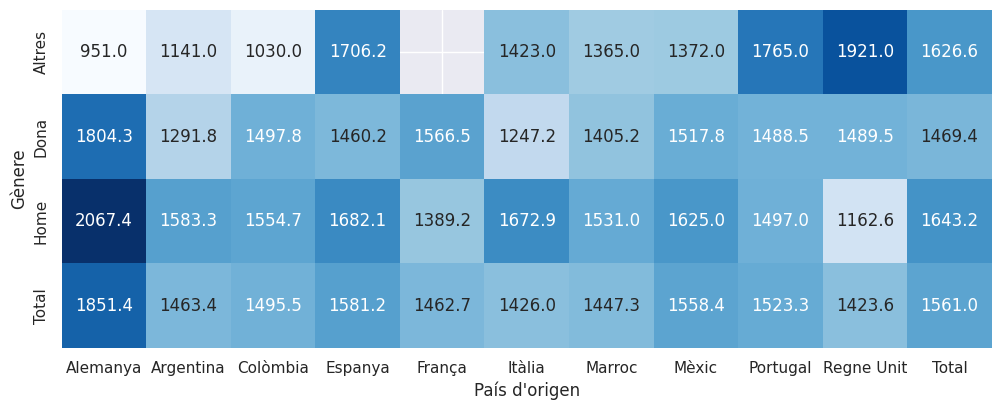

In [71]:
# Código para hacerlo con sns, descartado para este caso en favor de los métodos de visualización propios de pandas.
# sns.set(rc={'figure.figsize':(12, 8)}) #Cambio el tamaño del lienzo del seaborn

# pd.crosstab(
#     df["Gènere"],df["País d'origen"], values=df['Salari mensual'], aggfunc='mean',
#     margins=True, margins_name="Total")\
#     .round(2)\
#     .pipe( sns.heatmap, cmap="Blues", annot=True, fmt=".1f", cbar=False, square=True )

In [70]:
pd.crosstab(
    df["Gènere"],df["País d'origen"], values=df['Salari mensual'], aggfunc='mean',
    margins=True, margins_name="Total")\
    .round(2)\
    .style.background_gradient( axis=None, cmap='Blues').format(precision=2)

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Total
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Total,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


#6.
Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.


In [101]:
def calculate_age( birth_date, now ):

  birtday_pass = 1 if ( (birth_date.month, birth_date.day) >= (now.month, now.day) ) else 0

  return now.year - birth_date.year - birtday_pass

df['Data de Naixament'] = pd.to_datetime(df[['Any', 'Mes', 'Dia']].rename(
    columns={'Any': 'year', 'Mes': 'month', 'Dia': 'day'}
), errors='coerce')

now = pd.Timestamp.now()
df['Edad'] = df['Data de Naixament'].apply( calculate_age, args=(now,) )

In [19]:
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascuda a Espanya,Data de Naixament,Edad
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951,No,Grup A,Mia Schneider Fischer,False,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769,Si,Grup B,Laura Schneider Fischer,False,1958-02-02,68
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013,No,Grup B,Lea Schneider Schneider,False,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557,Si,Grup B,Mia Fischer,False,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754,Si,Grup D,Jonas Schneider,False,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033,No,Grup B,Emily Taylor Jones,False,1958-03-28,68
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130,Si,Grup A,George Brown Jones,False,1979-12-27,46
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023,No,Grup A,Olivia Brown Brown,False,1952-08-28,73


# Nivel 2

##1.
Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.

Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

```
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})
```




In [102]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})
df = df.join( df_increment.set_index("Grup"), on="Grup Professional", how="left")

factor_incremento = (
    df["Increment"]
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors='coerce') / 100
)

df["Salari mensual"] = (df["Salari mensual"] * (1 + factor_incremento)).round(2)

In [89]:
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascuda a Espanya,Increment
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.55,No,Grup A,Mia Schneider Fischer,False,5%
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.92,Si,Grup B,Laura Schneider Fischer,False,"3,5%"
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.46,No,Grup B,Lea Schneider Schneider,False,"3,5%"
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.50,Si,Grup B,Mia Fischer,False,"3,5%"
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.32,Si,Grup D,Jonas Schneider,False,8%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.15,No,Grup B,Emily Taylor Jones,False,"3,5%"
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.50,Si,Grup A,George Brown Jones,False,5%
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.15,No,Grup A,Olivia Brown Brown,False,5%


##2.

Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o ) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o  que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [103]:
groups = df['Grup Professional'].unique()

for group in groups:
  df[df['Grup Professional'] == group].to_csv(f"dades_{group}", sep=';',index=False,encoding= "utf-8-sig",header=True, decimal=',')

In [104]:
df_group = df.groupby('Grup Professional').agg(
    nombre_treballadors   = ('Salari mensual','size'),
    salari_mitja          = ('Salari mensual','mean'),
    edad_mitja            = ('Edad','mean')
).round(2).rename( columns = {'nombre_treballadors':'Nombre Treballadors', 'salari_mitja': 'Salari mitjà', 'edad_mitja': 'Edad mitjana'})

df_group.to_csv("dades_Mitja", sep=';',index=True, encoding= "utf-8-sig",header=True, decimal=',')

#Nivel 3

##1.
Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

    un histograma/boxplot si la variable és numèrica
    unes barres dels valors més freqüents si és categòrica
    unes barres dels anys més freqüents si la dada està en format data.

La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

In [23]:
#
#Es un extra, hecho por gusto.
#
def get_csv_dataframe_from_url( dataset ):

  url = f"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/{dataset}.csv"

  try:
    df = pd.read_csv( url, sep = ',')
  except:
    print( "Algo no fue bien, comprueba tu conexión" )
    df = False

  return df

def request_dataset_to_user():

  url_base = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/"

  dataset_list = ['titanic','tips', 'taxis', 'seaice', 'planets',
                  'penguins', 'iris', 'mpg', 'healthexp', 'glue',
                  'geyser', 'fmri', 'flights', 'diamonds']

  print("Selecciona un dataset para su representación gráfica de la siguiente lista:")

  for index, dataset in enumerate(dataset_list, start=1):
    print(f"{dataset}", end="\n" if (index % 5 == 0) else ", ")


  selected = input("\n")
  while selected not in dataset_list:
      print("No tenemos ese dataset, elije uno de la lista.")
      selected = input()

  return selected


In [24]:
def generate_graphic_ds( dataset, save=False ):

  list_graphic = []

  columns_kind = {
    'numeric': df.select_dtypes(include=["number"] ).nunique(),
    'others': df.select_dtypes(exclude=["number"] ).nunique()
  }

  for kind, columns in columns_kind.items():
    for column, n_values in columns.items():
      grp = plt.subplots(figsize=(8, 6))

      match ( kind, n_values):
        case( _, x) if x < 3:
            df_group = df.groupby(column, as_index=False).size()
            grp = plt.pie( x=df_group['size'], labels=df_group[column], autopct='%1.1f%%', startangle=90 )

        case( _, _) if 'year' in column:
            u_values = df[column].unique()
            grp = sns.histplot( data=df, y=column, discrete = True, shrink=0.8)
            grp.set_yticks(u_values)
            grp.set_yticklabels(u_values)

        case( "numeric", _ ):
            grp = sns.histplot( data=df, x=column, discrete = False )

        case( _, _):
            grp = sns.countplot( data=df, y=column )
            grp.bar_label( grp.containers[0], fontsize=8 )

      list_graphic.append( grp )

      if save:
        plt.savefig( f"{dataset}_graphic_{column}.png", bbox_inches='tight' )

      plt.title(f"{column} has {n_values} values")
      plt.show()
      plt.close()


  return list_graphic

In [25]:
selected_ds = request_dataset_to_user()
df = get_csv_dataframe_from_url( selected_ds )

Selecciona un dataset para su representación gráfica de la siguiente lista:
titanic, tips, taxis, seaice, planets
penguins, iris, mpg, healthexp, glue
geyser, fmri, flights, diamonds, 
penguins


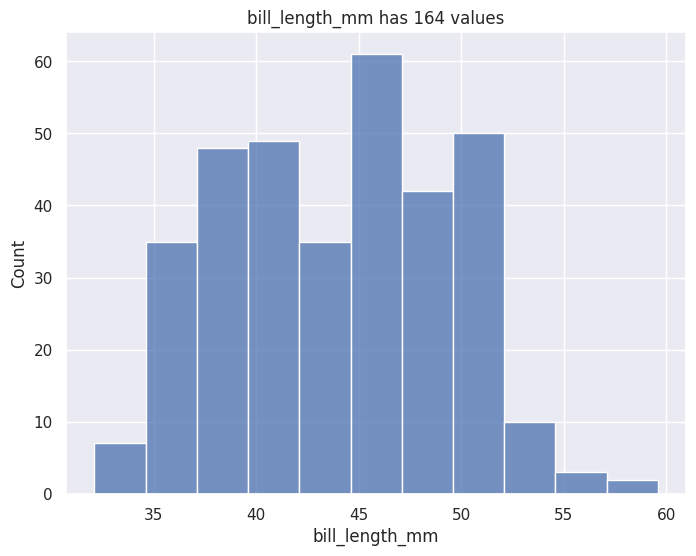

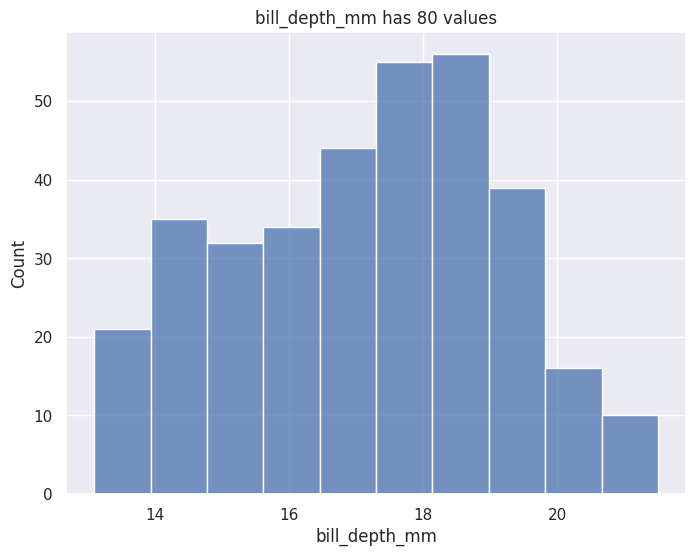

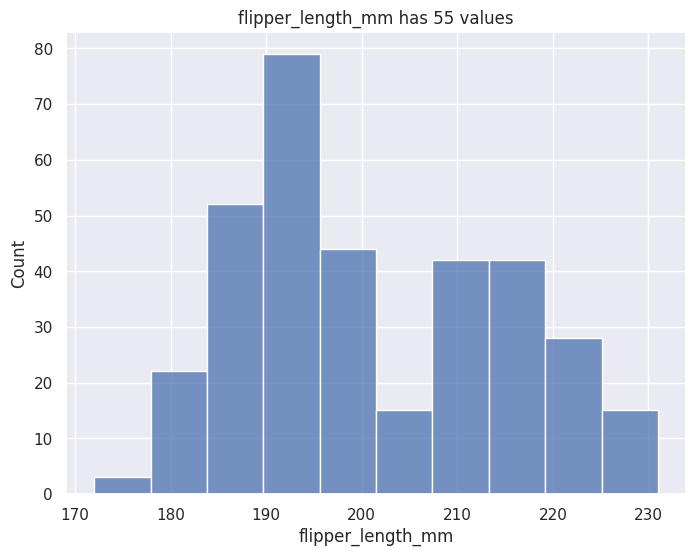

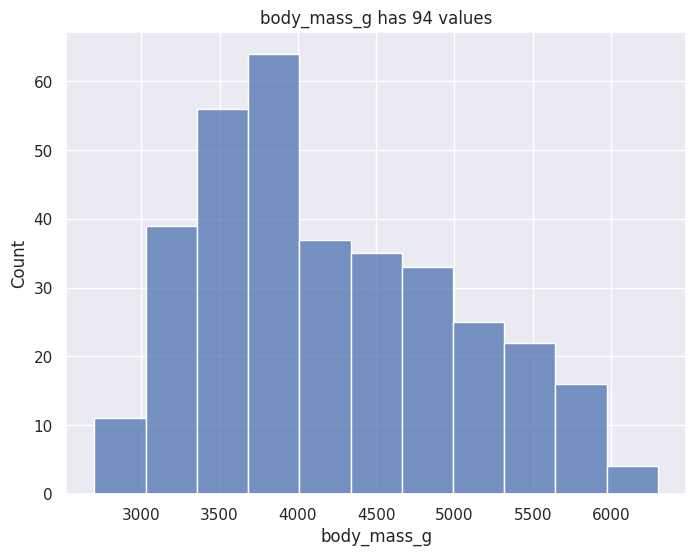

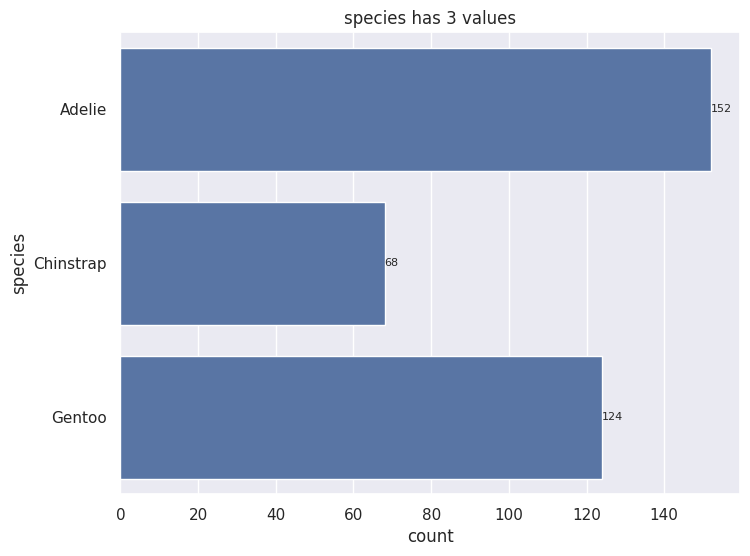

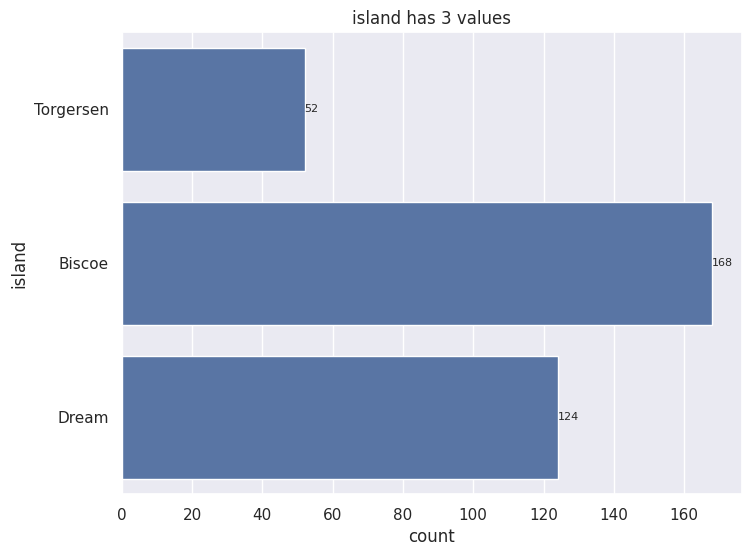

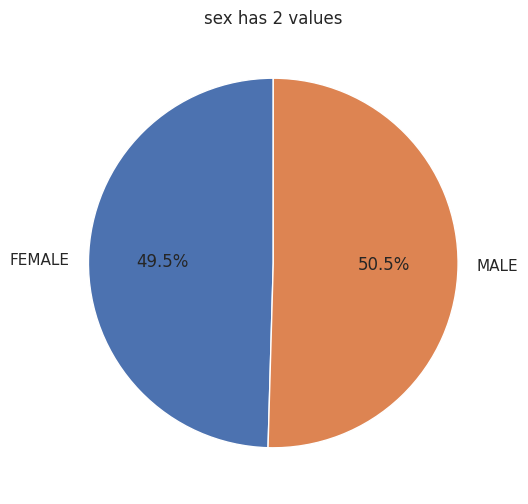

In [26]:
graphics = generate_graphic_ds( selected_ds )

#2.

Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: Mejores Rutas

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat

In [27]:
df = open_data_file( "matriu_distancies.xlsx", "Distancia (kilómetros)", header=0, index_col=0 )

In [28]:
df.drop(index=['Palma','Las Palmas de Gran Canaria'], columns=['Palma','Las Palmas de Gran Canaria'], inplace=True)

In [29]:
df

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


In [30]:
def request_start_city( cities ):

  city_opt = cities.tolist()
  city_opt.append('All')

  print("¿Desde que ciudad quieres empezar?:")
  print(f"{[city for city in city_opt]}")
  city = input("\n")

  while city not in city_opt:
    print("Esa ciudad no esta disponible, elige una de la lista")
    city = input()

  return city


In [31]:
def get_direct_min_route( city ):

  remain_cities = cities.drop(city)
  route_dicc = [{'city':city,'dist':0}]

  df_route = df.copy()

  while remain_cities.values.size > 0:

    next_city = df_route[city].idxmin()
    route_dicc.append( {'city':next_city, 'dist':df_route[city].loc[next_city]} )

    df_route.drop(city, inplace=True)
    remain_cities = remain_cities.drop(next_city)
    city = next_city

  return route_dicc

In [32]:
def get_format_route( route ):

  path  = " -> ".join( value['city'] for value in route )
  km    = sum( value['dist'] for value in route )

  return {'route':path, 'distance': km }

In [33]:
def random_improve_route( route ):

  format_route = get_format_route( route )
  lng_path = len( route )

  for i in range( 0, 10000 ):

    index_org = np.random.randint( 0, lng_path )
    index_end = np.random.randint( 0, lng_path )

    if index_org == index_end:
      continue

    route_opt2 = copy.deepcopy( route )

    route_opt2[index_end] = {
        'city':route[index_org]['city'],
        'dist':df[route[index_end-1]['city']].loc[route[index_org]['city']]}

    route_opt2[index_org] = {
        'city':route[index_end]['city'],
        'dist':df[route[index_org-1]['city']].loc[route[index_end]['city']]}

    if ( index_end < lng_path - 1 ):
      route_opt2[index_end+1].update({'dist':df[route_opt2[index_end]['city']].loc[route_opt2[index_end+1]['city']] })

    if ( index_org < lng_path - 1 ):
      route_opt2[index_org+1].update({'dist':df[route_opt2[index_org]['city']].loc[route_opt2[index_org+1]['city']] })

    format_route_opt2 = get_format_route( route_opt2 )
    if ( format_route_opt2['distance'] < format_route['distance'] ):
      route         = copy.deepcopy( route_opt2 )
      format_route  = get_format_route( route )

  return route



In [34]:
def get_best_route( routes ):
  return min( results, key=lambda x: x['distance'])

In [35]:
cities        = df.columns
start_city    = request_start_city( cities )

results = []
city_list = [start_city] if start_city != 'All' else cities

for city_0 in city_list:
  route   = get_direct_min_route( city_0 )
  route   = random_improve_route( route )
  results.append( get_format_route( route ) )

¿Desde que ciudad quieres empezar?:
['Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Málaga', 'Murcia', 'Bilbao', 'Alicante', 'Córdoba', 'Valladolid', 'Vigo', 'Gijón', 'Hospitalet de Llobregat', 'All']

Barcelona


In [36]:
get_best_route( results )

{'route': 'Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Málaga -> Sevilla -> Córdoba -> Valladolid -> Bilbao -> Gijón -> Vigo',
 'distance': np.float64(2462.0)}